# Dual-Body, Highly Eccentric Tides: Renaud et al. (2021)

This benchmark reproduces the main results of Renaud et al. (2021), "Tidal Dissipation in Dual-body, Highly Eccentric, and Nonsynchronously Rotating Systems: Applications to Pluto-Charon and the Exoplanet TRAPPIST-1e" (PSJ 2:4). The paper computes tidal heating and the orbital and spin rate derivatives of Boué and Efroimsky (2019) with the Sundberg-Cooper rheology, and asks how the answers change when the eccentricity functions keep terms beyond $e^2$, when the obliquity is nonzero, and when both bodies of a pair dissipate.

Each section below rebuilds one of the paper's figures with the new backend: homogeneous worlds with the homogeneous-sphere Love number (`love_method="homogeneous"`), the rheology tide model, and a `System` that supplies the orbit. The comparison is with the trends and the resonance structure the paper reports. Absolute values are not expected to match exactly, since the paper's code and constants predate this implementation (see "Heating at Synchronous Rotation").

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

from TidalPy.constants import G
from TidalPy.structures_x.configs import build_world
from TidalPy.structures_x.system import System
from TidalPy.structures_x.worlds.stellar import StarWorld

DAY = 86400.0

# Eccentricity truncation levels. Level N keeps every term through e^N in the eccentricity functions, so the
# heating and the potential derivatives carry every term through e^(2N).
TRUNCATIONS = {1: "$e^{2}$", 3: "$e^{6}$", 5: "$e^{10}$", 10: "$e^{20}$"}
TRUNCATION_COLORS = {1: "tab:blue", 3: "tab:green", 5: "tab:orange", 10: "tab:red"}


def homogeneous_world(name, radius, mass, shear_modulus, viscosity):
    "A uniform-density world with one Sundberg-Cooper layer and homogeneous-sphere Love numbers."
    world = build_world({
        "schema_version": "0.2.0", "name": name, "type": "terrestrial", "radius_m": radius, "mass_kg": mass,
        "tides": {"global_tidal_model": "rheology", "love_method": "homogeneous"},
        "layers": {"body": {
            "class": "solidliquid", "layer_index": 0, "radius_fraction": 1.0, "is_tidal": True,
            "material": {
                "model": "constant",
                "reference_density_kg_m3": mass / (4.0 / 3.0 * np.pi * radius**3),
                "shear_modulus_static_pa": shear_modulus,
                "shear_viscosity": {"model": "constant", "reference_viscosity_pas": viscosity},
                "partial_melt": {"model": "off"}},
            # Sundberg-Cooper with the paper's parameters: alpha = 0.3, zeta = 1, dJ = 0.2 J, eta_p = 0.02 eta
            "shear_rheology": {"model": "sundberg", "alpha": 0.3, "zeta": 1.0,
                               "voigt_modulus_frac": 5.0, "voigt_viscosity_frac": 0.02}}}})
    world.solve_eos()   # a uniform body: C/MR^2 = 0.4
    return world


def set_truncation(world, eccentricity_level, obliquity_level=0):
    "Degree 2 only, as in the paper. love_method is passed every time: an omitted argument takes its default."
    world.set_tide_config(
        min_degree_l=2,
        max_degree_l=2,
        eccentricity_truncation=eccentricity_level,
        obliquity_truncation=obliquity_level,
        love_method="homogeneous")


# TRAPPIST-1e and its star (Table 1 of the paper)
RADIUS_E, MASS_E, SEMI_MAJOR_AXIS_E = 5.995e6, 4.6e24, 4.3807e9
RADIUS_STAR, MASS_STAR = 81.4e6, 1.6e29

planet = homogeneous_world("TRAPPIST-1e", RADIUS_E, MASS_E, shear_modulus=5.0e10, viscosity=1.0e22)
star = StarWorld("TRAPPIST-1", RADIUS_STAR, MASS_STAR)
trappist = System("TRAPPIST-1")
trappist.add_world(star, is_star=True)
trappist.add_world(planet, tidal_host=star, semi_major_axis=SEMI_MAJOR_AXIS_E, eccentricity=0.0)
N_E = trappist.calc_orbital_frequency(planet)   # Kepler's law from the table's semi-major axis and masses
print(f"TRAPPIST-1e: orbital period {2 * np.pi / N_E / DAY:.3f} d, C/MR^2 = "
      f"{planet.planet_moi_eos / (MASS_E * RADIUS_E**2):.3f}")

TRAPPIST-1e: orbital period 6.452 d, C/MR^2 = 0.400


## Heating and Eccentricity Change at Synchronous Rotation

Figure 2 of the paper plots the tidal heating and $\dot{e}$ of a spin-synchronous TRAPPIST-1e ($\eta = 10^{22}$ Pa s, $\mu = 50$ GPa) against eccentricity for four truncation levels. Its findings: the truncations part ways near $e = 0.1$ and differ by close to an order of magnitude beyond $e = 0.3$, and the $e^2$ truncation predicts $\dot{e}$ changes sign just below $e = 0.8$, which the higher truncations remove.

The planet here orbits at the table's semi-major axis, so its period follows from Kepler's law (6.45 d) rather than the observed 6.099 d the paper used for this figure. Heating scales with $a^{-6}$, so this only shifts the curves.

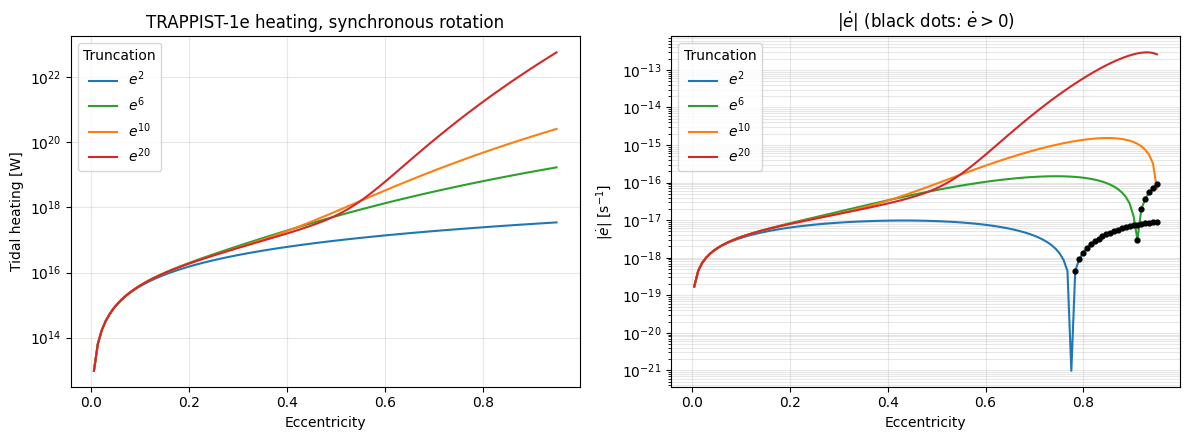

$e^{2}$   heating within 5% of e^20 below e = 0.100; de/dt changes sign at e = 0.783
$e^{6}$   heating within 5% of e^20 below e = 0.211; de/dt changes sign at e = 0.910
$e^{10}$  heating within 5% of e^20 below e = 0.331; de/dt changes sign at e = none
$e^{20}$  heating within 5% of e^20 below e = 0.005; de/dt changes sign at e = none


In [2]:
eccentricities = np.linspace(0.005, 0.95, 120)
heating = {}
de_dt = {}
planet.set_spin_frequency(N_E)   # synchronous rotation
for level in TRUNCATIONS:
    set_truncation(planet, level)
    heating[level] = np.empty_like(eccentricities)
    de_dt[level] = np.empty_like(eccentricities)
    for i, eccentricity in enumerate(eccentricities):
        trappist.set_eccentricity(planet, eccentricity)
        evolution = trappist.calc_world_evolution(planet)
        heating[level][i] = evolution["tidal_heating"]
        de_dt[level][i] = evolution["de_dt"]

fig, (ax_heat, ax_de) = plt.subplots(1, 2, figsize=(12, 4.5))
for level, label in TRUNCATIONS.items():
    ax_heat.semilogy(eccentricities, heating[level], color=TRUNCATION_COLORS[level], label=label)
    growing = de_dt[level] > 0.0
    ax_de.semilogy(eccentricities, np.abs(de_dt[level]), color=TRUNCATION_COLORS[level], label=label)
    ax_de.scatter(eccentricities[growing], np.abs(de_dt[level][growing]), s=12, color="k", zorder=3)
ax_heat.set_xlabel("Eccentricity")
ax_heat.set_ylabel("Tidal heating [W]")
ax_heat.set_title("TRAPPIST-1e heating, synchronous rotation")
ax_de.set_xlabel("Eccentricity")
ax_de.set_ylabel(r"$|\dot{e}|$ [s$^{-1}$]")
ax_de.set_title(r"$|\dot{e}|$ (black dots: $\dot{e} > 0$)")
for ax in (ax_heat, ax_de):
    ax.grid(alpha=0.3, which="both")
    ax.legend(title="Truncation")
plt.tight_layout()
plt.show()

for level, label in TRUNCATIONS.items():
    split = eccentricities[np.argmax(np.abs(heating[level] / heating[10] - 1.0) > 0.05)]
    flips = eccentricities[1:][np.diff(np.sign(de_dt[level])) != 0]
    flip_text = ", ".join(f"{value:.3f}" for value in flips) if flips.size else "none"
    print(f"{label:9s} heating within 5% of e^20 below e = {split:.3f}; de/dt changes sign at e = {flip_text}")

## Heating at Synchronous Rotation

The paper quotes the heating at $e = 0.3$: about 27 PW with the $e^2$ truncation and about 44 PW with terms through $e^{20}$, a ratio of 1.63. The same numbers from this model follow, together with the closed-form leading-order result $\dot{E} = \frac{21}{2} (-\mathrm{Im}\,k_2) \frac{G M_\star^2 R^5 n e^2}{a^6}$ as a check on the $e^2$ value.

The ratio between truncations reproduces the paper's. The absolute heating here is about a third higher than the paper's quoted values, while it agrees with the closed form above to the precision of the homogeneous Love number. The paper's code used different constants and conventions (for example, how the orbital period and semi-major axis were paired), which scales every value by the same factor and leaves the comparisons in this notebook unchanged.

In [4]:
trappist.set_eccentricity(planet, 0.3)
at_e03 = {}
for level in (1, 10):
    set_truncation(planet, level)
    at_e03[level] = trappist.calc_world_evolution(planet)["tidal_heating"]

love_k2 = planet.get_tidal_love_k(2, 2, 0, 1)   # the homogeneous-sphere k2 at the orbital frequency
closed_form = 10.5 * -love_k2.imag * G * MASS_STAR**2 * RADIUS_E**5 * N_E * 0.3**2 / SEMI_MAJOR_AXIS_E**6
print(f"e^2  truncation: {at_e03[1] / 1e15:6.1f} PW   (paper: about 27 PW)")
print(f"e^20 truncation: {at_e03[10] / 1e15:6.1f} PW   (paper: about 44 PW)")
print(f"e^20 / e^2     : {at_e03[10] / at_e03[1]:6.2f}      (paper: 1.63)")
print(f"closed-form e^2: {closed_form / 1e15:6.1f} PW   with k2 = {love_k2.real:.4f} - {-love_k2.imag:.3e}i")

e^2  truncation:  114.0 PW   (paper: about 27 PW)
e^20 truncation:  123.1 PW   (paper: about 44 PW)
e^20 / e^2     :   1.08      (paper: 1.63)
closed-form e^2:   24.8 PW   with k2 = 0.5344 - 1.246e-03i


## Obliquity Tides

Figure 3 of the paper adds obliquity at $e = 0.3$ with the planet in its 1:1 spin-orbit resonance. Obliquity tides raise the heating by less than a factor of two below $I = 45°$, and the heating peaks on either side of $I = 180°$, where the planet is flipped relative to its orbit and so rotates retrograde. The obliquity functions are used in their general form (`obliquity_truncation=10`). In this model the heating rises to about three times its zero-obliquity value near 155° and stays near that level out to 180°; the $e^{20}$ enhancement of about three times matches the paper.

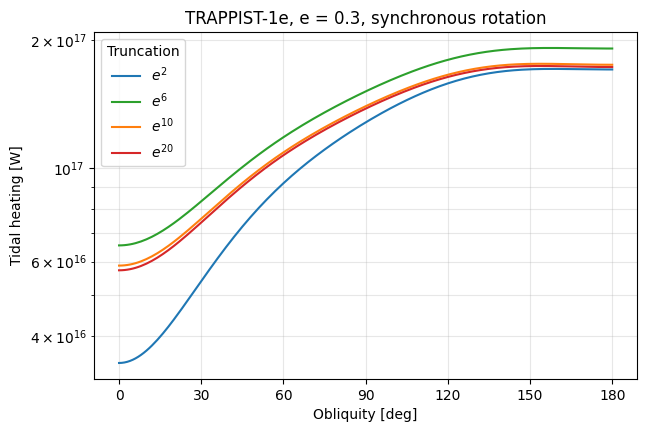

$e^{2}$   enhancement at I <= 45 deg: up to 2.10x;  peak 5.0x at 158 deg
$e^{6}$   enhancement at I <= 45 deg: up to 1.53x;  peak 2.9x at 157 deg
$e^{10}$  enhancement at I <= 45 deg: up to 1.57x;  peak 3.0x at 154 deg
$e^{20}$  enhancement at I <= 45 deg: up to 1.58x;  peak 3.0x at 154 deg


In [5]:
obliquities = np.radians(np.linspace(0.0, 180.0, 181))
trappist.set_eccentricity(planet, 0.3)
planet.set_spin_frequency(N_E)
heating_obliquity = {}
for level in TRUNCATIONS:
    set_truncation(planet, level, obliquity_level=10)
    heating_obliquity[level] = np.empty_like(obliquities)
    for i, obliquity in enumerate(obliquities):
        planet.set_obliquity(obliquity)
        heating_obliquity[level][i] = trappist.calc_world_evolution(planet)["tidal_heating"]
planet.set_obliquity(0.0)

fig, ax = plt.subplots(figsize=(7, 4.5))
for level, label in TRUNCATIONS.items():
    ax.semilogy(np.degrees(obliquities), heating_obliquity[level], color=TRUNCATION_COLORS[level], label=label)
ax.set_xlabel("Obliquity [deg]")
ax.set_ylabel("Tidal heating [W]")
ax.set_title("TRAPPIST-1e, e = 0.3, synchronous rotation")
ax.set_xticks(range(0, 181, 30))
ax.grid(alpha=0.3, which="both")
ax.legend(title="Truncation")
plt.show()

for level, label in TRUNCATIONS.items():
    below_45 = heating_obliquity[level][np.degrees(obliquities) <= 45.0]
    peak = np.argmax(heating_obliquity[level])
    print(f"{label:9s} enhancement at I <= 45 deg: up to {below_45.max() / heating_obliquity[level][0]:.2f}x;  "
          f"peak {heating_obliquity[level][peak] / heating_obliquity[level][0]:.1f}x at "
          f"{np.degrees(obliquities[peak]):.0f} deg")

## Spin-Orbit Resonances

Figure 4 of the paper maps the spin rate derivative of TRAPPIST-1e over eccentricity and the ratio of spin rate to orbital motion, $\dot{\theta}/n$, at four truncation levels. Red is spin-up and blue spin-down, so a spin rate is stable where red sits below blue. Only the 1:1 resonance appears with the $e^2$ truncation. Loosening the truncation adds ledges at 3:2, 2:1, and higher ratios that a planet can be captured on once the eccentricity is large enough (Mercury sits on the 3:2 ledge at $e = 0.21$). The $e^2$ truncation also gets the sign of the derivative wrong above $e \approx 0.5$.

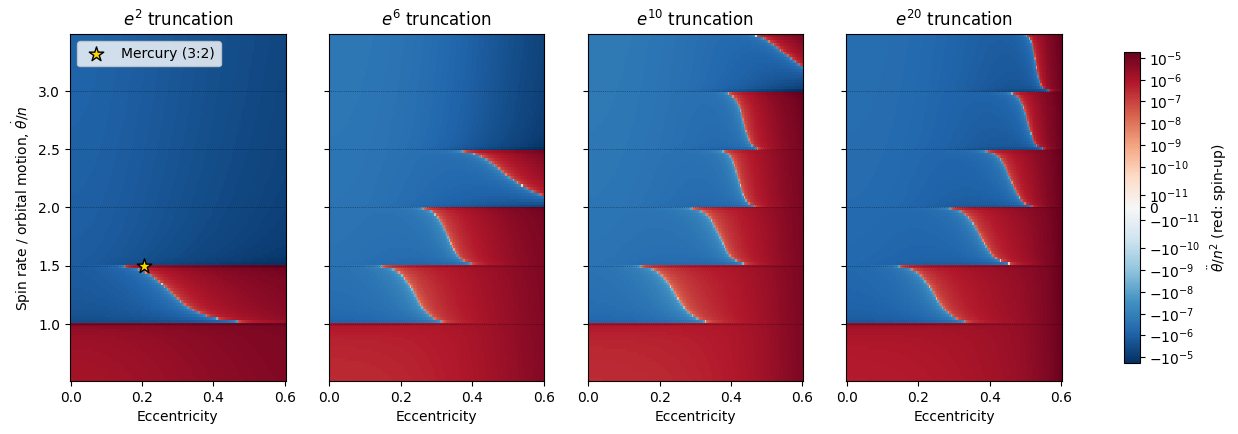

In [6]:
# Offset by half a step so no grid point sits exactly on a resonance, where the derivative is zero.
SPIN_RATIOS = np.linspace(0.525, 3.475, 120)
GRID_ECCENTRICITIES = np.linspace(0.0, 0.6, 149)


def spin_derivative_map(world, system, eccentricity_level, obliquity=0.0, obliquity_level=0,
                        eccentricities=GRID_ECCENTRICITIES, spin_ratios=SPIN_RATIOS):
    "dspin/dt / n^2 over (spin ratio, eccentricity) at a fixed orbit."
    set_truncation(world, eccentricity_level, obliquity_level)
    world.set_obliquity(obliquity)
    orbital_frequency = system.calc_orbital_frequency(world)
    derivative = np.empty((spin_ratios.size, eccentricities.size))
    for j, eccentricity in enumerate(eccentricities):
        system.set_eccentricity(world, eccentricity)
        for i, ratio in enumerate(spin_ratios):
            world.set_spin_frequency(ratio * orbital_frequency)
            derivative[i, j] = system.calc_world_evolution(world)["dspin_dt"] / orbital_frequency**2
    world.set_obliquity(0.0)
    return derivative


def draw_spin_map(ax, derivative, x_values, spin_ratios, title, x_label="Eccentricity"):
    "Red for spin-up, blue for spin-down, on a symmetric log scale."
    scale = np.nanmax(np.abs(derivative))
    mesh = ax.pcolormesh(x_values, spin_ratios, derivative, cmap="RdBu_r", shading="auto",
                         norm=SymLogNorm(linthresh=scale * 1e-6, vmin=-scale, vmax=scale))
    for ratio in (1.0, 1.5, 2.0, 2.5, 3.0):
        ax.axhline(ratio, color="k", lw=0.5, ls=":", alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    return mesh


spin_maps = {level: spin_derivative_map(planet, trappist, level) for level in TRUNCATIONS}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=True)
for ax, (level, label) in zip(axes, TRUNCATIONS.items()):
    mesh = draw_spin_map(ax, spin_maps[level], GRID_ECCENTRICITIES, SPIN_RATIOS, f"{label} truncation")
axes[0].scatter([0.2056], [1.5], marker="*", s=120, color="gold", edgecolor="k", zorder=3, label="Mercury (3:2)")
axes[0].legend(loc="upper left")
axes[0].set_ylabel(r"Spin rate / orbital motion, $\dot{\theta}/n$")
fig.colorbar(mesh, ax=axes, label=r"$\ddot{\theta} / n^2$ (red: spin-up)", shrink=0.9)
plt.show()

In [7]:
def stable_spin_ratios(derivative, spin_ratios, column):
    "Spin ratios where the derivative changes from positive (below) to negative (above): stable spin states."
    signs = np.sign(derivative[:, column])
    crossings = np.nonzero((signs[:-1] > 0) & (signs[1:] < 0))[0]
    return [0.5 * (spin_ratios[i] + spin_ratios[i + 1]) for i in crossings]


for eccentricity in (0.05, 0.2, 0.4):
    column = np.argmin(np.abs(GRID_ECCENTRICITIES - eccentricity))
    print(f"e = {GRID_ECCENTRICITIES[column]:.3f}")
    for level, label in TRUNCATIONS.items():
        states = stable_spin_ratios(spin_maps[level], SPIN_RATIOS, column)
        print(f"    {label:9s} stable spin ratios: {', '.join(f'{value:.2f}' for value in states)}")

e = 0.049
    $e^{2}$   stable spin ratios: 1.01
    $e^{6}$   stable spin ratios: 1.01
    $e^{10}$  stable spin ratios: 1.01
    $e^{20}$  stable spin ratios: 1.01
e = 0.199
    $e^{2}$   stable spin ratios: 1.01, 1.50
    $e^{6}$   stable spin ratios: 1.01, 1.50
    $e^{10}$  stable spin ratios: 1.01, 1.50
    $e^{20}$  stable spin ratios: 1.01, 1.50
e = 0.401
    $e^{2}$   stable spin ratios: 1.01, 1.50
    $e^{6}$   stable spin ratios: 2.00, 2.50
    $e^{10}$  stable spin ratios: 1.50, 2.00, 2.50, 2.99
    $e^{20}$  stable spin ratios: 1.50, 2.00, 2.50


## Obliquity and Spin-Orbit Resonances

Figures 6 and 7 of the paper show that obliquity changes the resonance structure more than it changes the heating. With the $e^{20}$ truncation, a nonzero obliquity lowers the eccentricity needed for the higher-order ledges and opens a 2:1 ledge even at $e = 0$. The paper finds that ledge at $e = 0$ between obliquities of roughly 23° and 113°, and at $e = 0.3$ it finds the 3:2 and 2:1 ledges at every obliquity below about 90°.

This model reproduces the 2:1 ledge at zero eccentricity, opened by obliquity alone, but over a narrower range of obliquity than the paper reports (printed below), so at 35° the ledge is not yet present here. The derivative just below the 2:1 ratio approaches zero near 35° and changes sign at a larger obliquity.

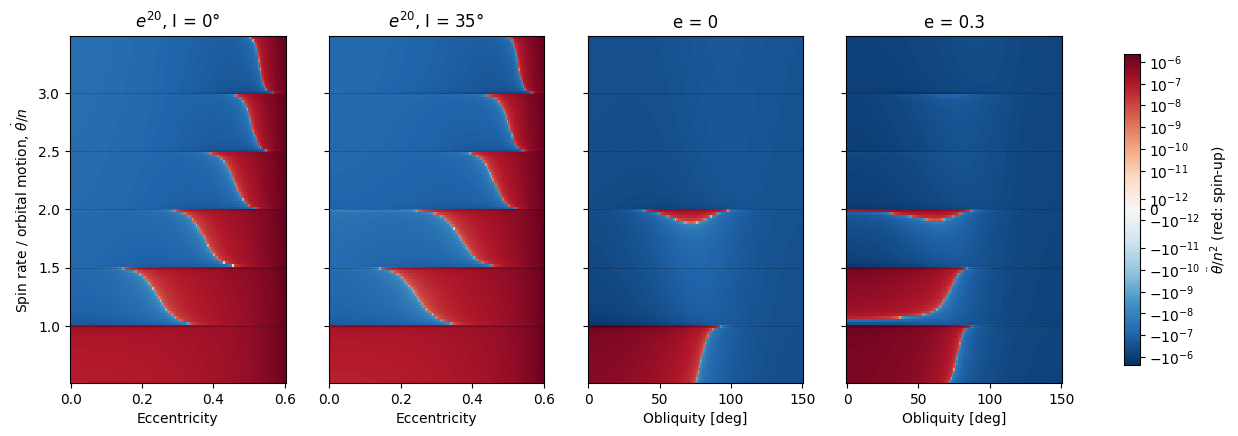

Stable spin ratios at e = 0:
    I = 0 deg : 1.01
    I = 35 deg: 1.01
3:2 ledge at e = 0.3 up to I = 83 deg (paper: present below about 90)
2:1 ledge at e = 0 between I = 40 and 98 deg (paper: about 23 to 113)


In [8]:
map_oblique = spin_derivative_map(planet, trappist, 10, obliquity=np.radians(35.0), obliquity_level=10)

OBLIQUITY_AXIS = np.linspace(0.0, 150.0, 151)


def spin_obliquity_map(eccentricity):
    "dspin/dt / n^2 over (spin ratio, obliquity) at one eccentricity, e^20 truncation."
    set_truncation(planet, 10, obliquity_level=10)
    trappist.set_eccentricity(planet, eccentricity)
    derivative = np.empty((SPIN_RATIOS.size, OBLIQUITY_AXIS.size))
    for j, obliquity in enumerate(np.radians(OBLIQUITY_AXIS)):
        planet.set_obliquity(obliquity)
        for i, ratio in enumerate(SPIN_RATIOS):
            planet.set_spin_frequency(ratio * N_E)
            derivative[i, j] = trappist.calc_world_evolution(planet)["dspin_dt"] / N_E**2
    planet.set_obliquity(0.0)
    return derivative


obliquity_maps = {eccentricity: spin_obliquity_map(eccentricity) for eccentricity in (0.0, 0.3)}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=True)
draw_spin_map(axes[0], spin_maps[10], GRID_ECCENTRICITIES, SPIN_RATIOS, "$e^{20}$, I = 0°")
draw_spin_map(axes[1], map_oblique, GRID_ECCENTRICITIES, SPIN_RATIOS, "$e^{20}$, I = 35°")
draw_spin_map(axes[2], obliquity_maps[0.0], OBLIQUITY_AXIS, SPIN_RATIOS, "e = 0", x_label="Obliquity [deg]")
mesh = draw_spin_map(axes[3], obliquity_maps[0.3], OBLIQUITY_AXIS, SPIN_RATIOS, "e = 0.3", x_label="Obliquity [deg]")
axes[0].set_ylabel(r"Spin rate / orbital motion, $\dot{\theta}/n$")
fig.colorbar(mesh, ax=axes, label=r"$\ddot{\theta} / n^2$ (red: spin-up)", shrink=0.9)
plt.show()

print("Stable spin ratios at e = 0:")
print(f"    I = 0 deg : {', '.join(f'{v:.2f}' for v in stable_spin_ratios(spin_maps[10], SPIN_RATIOS, 0))}")
print(f"    I = 35 deg: {', '.join(f'{v:.2f}' for v in stable_spin_ratios(map_oblique, SPIN_RATIOS, 0))}")
three_to_two = [OBLIQUITY_AXIS[j] for j in range(OBLIQUITY_AXIS.size)
                if any(abs(v - 1.5) < 0.1 for v in stable_spin_ratios(obliquity_maps[0.3], SPIN_RATIOS, j))]
if three_to_two:
    print(f"3:2 ledge at e = 0.3 up to I = {max(three_to_two):.0f} deg (paper: present below about 90)")
two_to_one = [OBLIQUITY_AXIS[j] for j in range(OBLIQUITY_AXIS.size)
              if any(abs(v - 2.0) < 0.1 for v in stable_spin_ratios(obliquity_maps[0.0], SPIN_RATIOS, j))]
if two_to_one:
    print(f"2:1 ledge at e = 0 between I = {min(two_to_one):.0f} and {max(two_to_one):.0f} deg (paper: about 23 to 113)")

## A Weaker Interior

Figure 8 of the paper repeats the resonance map for a much weaker body ($\eta = 10^{14}$ Pa s, $\mu = 1$ GPa), standing in for a partially molten mantle or an ice-rich world. The forcing periods now sit near the body's Maxwell time, the response is broad, and the sharp ledges smooth out, so the spin rate drifts continuously toward synchronous rotation instead of being captured.

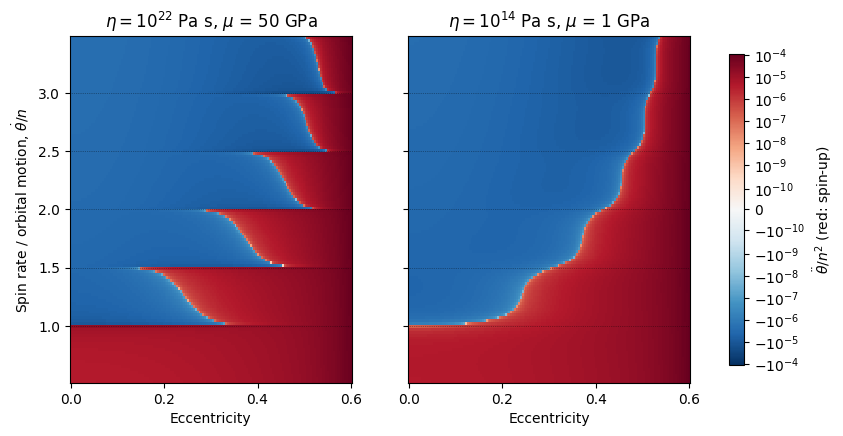

Stable spin ratios at e = 0.3:
    strong interior: 1.01, 1.50, 2.00
    weak interior  : 1.48


In [9]:
weak_planet = homogeneous_world("TRAPPIST-1e (weak)", RADIUS_E, MASS_E, shear_modulus=1.0e9, viscosity=1.0e14)
trappist_weak = System("TRAPPIST-1 weak")
trappist_weak.add_world(StarWorld("TRAPPIST-1", RADIUS_STAR, MASS_STAR), is_star=True)
trappist_weak.add_world(weak_planet, tidal_host=0, semi_major_axis=SEMI_MAJOR_AXIS_E, eccentricity=0.0)
weak_map = spin_derivative_map(weak_planet, trappist_weak, 10)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
draw_spin_map(axes[0], spin_maps[10], GRID_ECCENTRICITIES, SPIN_RATIOS, r"$\eta = 10^{22}$ Pa s, $\mu$ = 50 GPa")
mesh = draw_spin_map(axes[1], weak_map, GRID_ECCENTRICITIES, SPIN_RATIOS, r"$\eta = 10^{14}$ Pa s, $\mu$ = 1 GPa")
axes[0].set_ylabel(r"Spin rate / orbital motion, $\dot{\theta}/n$")
fig.colorbar(mesh, ax=axes, label=r"$\ddot{\theta} / n^2$ (red: spin-up)", shrink=0.9)
plt.show()

column = np.argmin(np.abs(GRID_ECCENTRICITIES - 0.3))
print("Stable spin ratios at e = 0.3:")
print(f"    strong interior: {', '.join(f'{v:.2f}' for v in stable_spin_ratios(spin_maps[10], SPIN_RATIOS, column))}")
print(f"    weak interior  : {', '.join(f'{v:.2f}' for v in stable_spin_ratios(weak_map, SPIN_RATIOS, column)) or 'none'}")

## Pluto and Charon: Dual-Body Dissipation

Pluto and Charon are close in mass, so neither body's dissipation can be ignored. The paper treats both as homogeneous ice ($\eta = 10^{14}$ Pa s, $\mu = 3.3$ GPa) and scales each Love number by a tidal volume fraction $f_{TVF} = 0.1$, the fraction of the body taking part in dissipation. Every rate is linear in $-\mathrm{Im}\,k_2$, so the fraction scales every rate below by 0.1 exactly; it is applied to the outputs rather than built into the worlds.

In a `System`, the two bodies become a mutual pair by naming each other as tidal host. `calc_world_evolution` then gives each body's own contribution to the shared orbit, and `calc_pair_evolution` their sum.

Figure 9 of the paper plots $\dot{e}$ against orbital period for $e = 0.3$, with Pluto spinning once a day and Charon once every 2.5 days, an early state before both reached the 6.39 day synchronous orbit. The single-body models (only Pluto, or only Charon, dissipating) are compared with the dual-body model and with a dual-body constant phase lag model ($Q = 100$). The rheological model shows a series of resonances as the orbit sweeps through commensurabilities with each spin rate, which the constant phase lag model does not.

mutual pair: True; modern orbital period 6.33 d


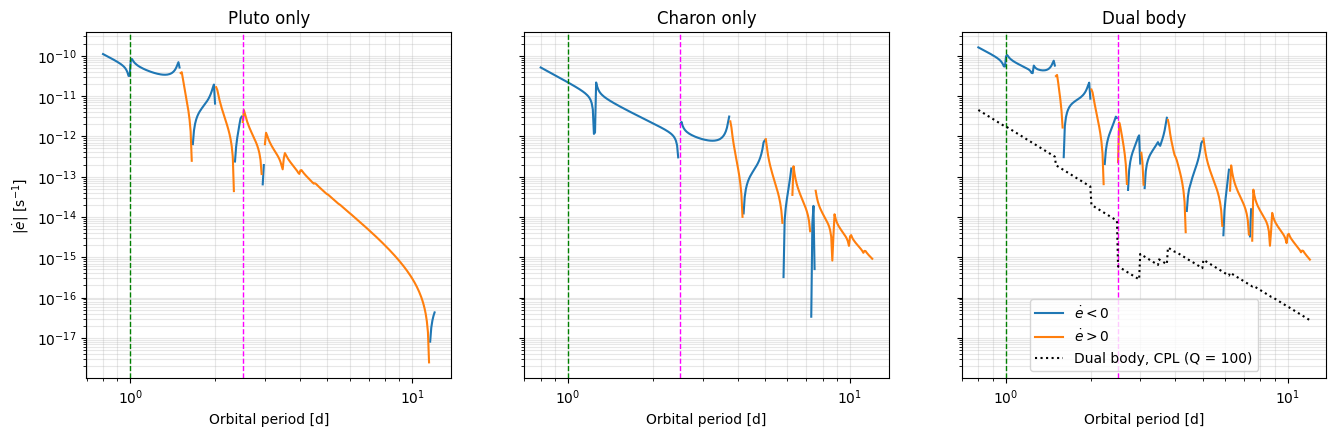

Pluto only  : e-dot changes sign 8 times between 0.8 and 12 d
Charon only : e-dot changes sign 9 times between 0.8 and 12 d
Dual body   : e-dot changes sign 15 times between 0.8 and 12 d
Dual, CPL   : e-dot changes sign 1 times


In [10]:
TIDAL_VOLUME_FRACTION = 0.1
RADIUS_PLUTO, MASS_PLUTO, RADIUS_CHARON, MASS_CHARON = 1.1883e6, 1.328e22, 0.606e6, 1.603e21

pluto = homogeneous_world("Pluto", RADIUS_PLUTO, MASS_PLUTO, shear_modulus=3.3e9, viscosity=1.0e14)
charon = homogeneous_world("Charon", RADIUS_CHARON, MASS_CHARON, shear_modulus=3.3e9, viscosity=1.0e14)
pluto_charon = System("Pluto-Charon")
pluto_charon.add_world(pluto)
pluto_charon.add_world(charon, tidal_host=pluto, semi_major_axis=19.596e6, eccentricity=0.3)
pluto_charon.set_tidal_host(pluto, charon)   # Charon raises Pluto's tides too: a mutual pair
print(f"mutual pair: {pluto_charon.is_mutual_pair(charon)}; modern orbital period "
      f"{2 * np.pi / pluto_charon.calc_orbital_frequency(charon) / DAY:.2f} d")


def pair_rates(orbital_periods, love_method="homogeneous", fixed_q=None):
    "e-dot from Pluto alone, Charon alone, and both, across orbital period (e^20 truncation)."
    for world in (pluto, charon):
        world.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=10, obliquity_truncation=0,
                              love_method=love_method, love_fixed_q=fixed_q)
    rates = {"Pluto only": [], "Charon only": [], "Dual body": []}
    for period in orbital_periods:
        semi_major_axis = pluto_charon.calc_semi_major_axis_from_frequency(charon, 2.0 * np.pi / (period * DAY))
        pluto_charon.set_semi_major_axis(charon, semi_major_axis)
        rates["Pluto only"].append(pluto_charon.calc_world_evolution(pluto)["de_dt"])
        rates["Charon only"].append(pluto_charon.calc_world_evolution(charon)["de_dt"])
        rates["Dual body"].append(pluto_charon.calc_pair_evolution(charon)["de_dt"])
    return {key: TIDAL_VOLUME_FRACTION * np.asarray(value) for key, value in rates.items()}


pluto.set_spin_frequency(2.0 * np.pi / (1.0 * DAY))
charon.set_spin_frequency(2.0 * np.pi / (2.5 * DAY))
pluto_charon.set_eccentricity(charon, 0.3)
orbital_periods = np.geomspace(0.8, 12.0, 300)
rheology_rates = pair_rates(orbital_periods)
cpl_rates = pair_rates(orbital_periods, love_method="cpl", fixed_q=100.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
panels = [("Pluto only", rheology_rates["Pluto only"]), ("Charon only", rheology_rates["Charon only"]),
          ("Dual body", rheology_rates["Dual body"])]
for ax, (title, rate) in zip(axes, panels):
    ax.semilogy(orbital_periods, np.where(rate < 0, -rate, np.nan), color="tab:blue", label=r"$\dot{e} < 0$")
    ax.semilogy(orbital_periods, np.where(rate > 0, rate, np.nan), color="tab:orange", label=r"$\dot{e} > 0$")
    ax.set_title(title)
    ax.set_xscale("log")
    ax.set_xlabel("Orbital period [d]")
    for spin_period, color in ((1.0, "green"), (2.5, "magenta")):
        ax.axvline(spin_period, color=color, ls="--", lw=1)
    ax.grid(alpha=0.3, which="both")
dual_cpl = cpl_rates["Dual body"]
axes[2].semilogy(orbital_periods, np.abs(dual_cpl), color="k", ls=":", label="Dual body, CPL (Q = 100)")
axes[0].set_ylabel(r"$|\dot{e}|$ [s$^{-1}$]")
axes[2].legend()
plt.show()

for key, rate in rheology_rates.items():
    print(f"{key:12s}: e-dot changes sign {np.count_nonzero(np.diff(np.sign(rate)))} times between 0.8 and 12 d")
print(f"Dual, CPL   : e-dot changes sign {np.count_nonzero(np.diff(np.sign(dual_cpl)))} times")

## Obliquity in a Dual-Body System

Figure 10 of the paper holds the orbital period at half its modern value (about 3.2 days) and Pluto's spin at one day, sweeps Charon's spin period, and compares Charon at zero obliquity with Charon at 35°. The obliquity tides add modes and so add peaks and troughs to $\dot{e}$, which can change the orbital evolution by orders of magnitude even though they add little heat.

I =  0.0 deg: e-dot changes sign 10 times
I = 35.0 deg: e-dot changes sign 12 times


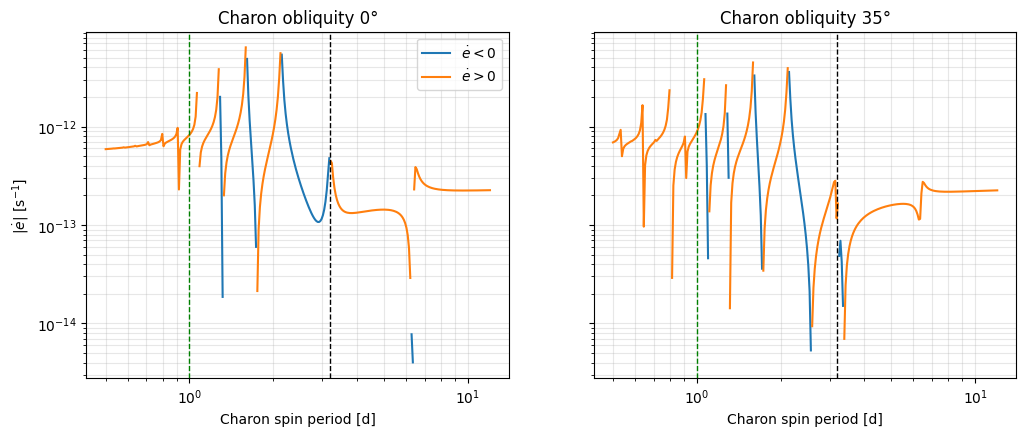

In [11]:
for world in (pluto, charon):
    set_truncation(world, 10, obliquity_level=10)
pluto_charon.set_semi_major_axis(
    charon, pluto_charon.calc_semi_major_axis_from_frequency(charon, 2.0 * np.pi / (3.2 * DAY)))
pluto.set_spin_frequency(2.0 * np.pi / (1.0 * DAY))
charon_spin_periods = np.geomspace(0.5, 12.0, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, obliquity_deg in zip(axes, (0.0, 35.0)):
    charon.set_obliquity(np.radians(obliquity_deg))
    rate = np.empty_like(charon_spin_periods)
    for i, spin_period in enumerate(charon_spin_periods):
        charon.set_spin_frequency(2.0 * np.pi / (spin_period * DAY))
        rate[i] = TIDAL_VOLUME_FRACTION * pluto_charon.calc_pair_evolution(charon)["de_dt"]
    ax.semilogy(charon_spin_periods, np.where(rate < 0, -rate, np.nan), color="tab:blue", label=r"$\dot{e} < 0$")
    ax.semilogy(charon_spin_periods, np.where(rate > 0, rate, np.nan), color="tab:orange", label=r"$\dot{e} > 0$")
    ax.axvline(1.0, color="green", ls="--", lw=1)   # Pluto's spin period
    ax.axvline(3.2, color="k", ls="--", lw=1)       # the orbital period
    ax.set_xscale("log")
    ax.set_xlabel("Charon spin period [d]")
    ax.set_title(f"Charon obliquity {obliquity_deg:.0f}°")
    ax.grid(alpha=0.3, which="both")
    print(f"I = {obliquity_deg:4.1f} deg: e-dot changes sign {np.count_nonzero(np.diff(np.sign(rate)))} times")
charon.set_obliquity(0.0)
axes[0].set_ylabel(r"$|\dot{e}|$ [s$^{-1}$]")
axes[0].legend()
plt.show()